In [2]:
import numpy as np

def getDW(t_pre, t_post, a_plus=0.01, tau_plus=20, a_minus=0.011, tau_minus=20):
    if t_pre <= t_post:
        return a_plus*np.exp((t_pre - t_post)/tau_plus)
    else:
        return -a_minus*np.exp(-(t_pre - t_post)/tau_minus)

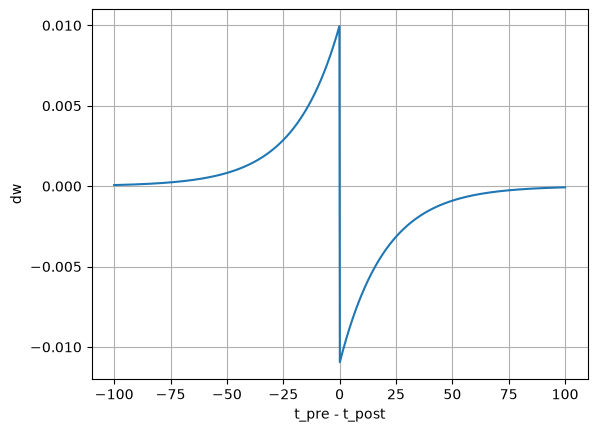

In [3]:
import matplotlib.pyplot as plt

t_pre = np.linspace(-100, 100, 1000)
t_post = 00
dw = [getDW(t, t_post) for t in t_pre]

plt.plot(t_pre, dw)
plt.xlabel('t_pre - t_post')
plt.ylabel('dw')
plt.grid(True)
plt.show()

## Implementing STDP
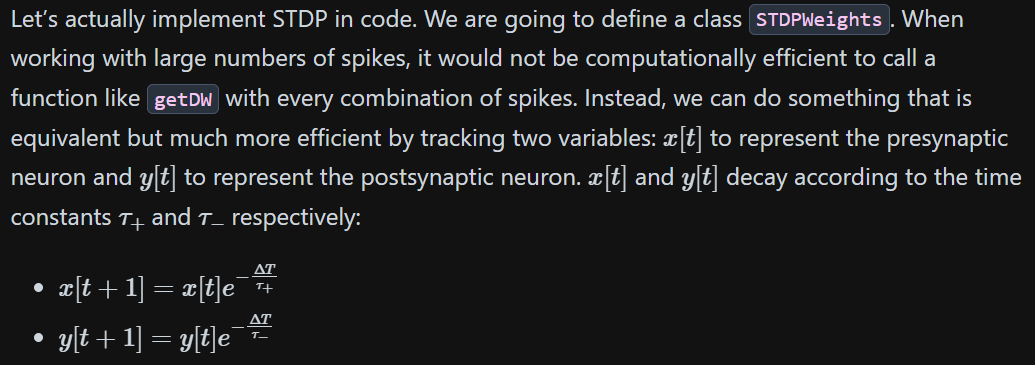

In [5]:
class STDPWeights:
    def __init__(self, numPre, numPost, tau_plus = 0.02, tau_minus = 0.02, a_plus = 0.01, a_minus = 0.011, g_min=0, g_max=1):
        self.numPre = numPre
        self.numPost = numPost
        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.a_plus = a_plus
        self.a_minus = a_minus
        self.x = np.zeros(numPre)
        self.y = np.zeros(numPost)

        self.g_min = g_min
        self.g_max = g_max
        self.w = np.zeros((numPre, numPost)) # A 2-D array; numPre x numPost zeros (normally would be random)


    def step(self, t_step):
        self.x = self.x * np.exp(-t_step/self.tau_plus)
        self.y = self.y * np.exp(-t_step/self.tau_minus)

    def updateWeights(self, preOutputs, postOutputs):
        self.x += (preOutputs  > 0) * self.a_plus
        self.y -= (postOutputs > 0) * self.a_minus

        alpha_g = self.g_max - self.g_min # Scaling factor for weight updates

        preSpikeIndices = np.where(preOutputs > 0)[0]   # Indices of pre-synaptic   spiking neurons
        postSpikeIndices = np.where(postOutputs > 0)[0]

        for ps_idx in preSpikeIndices:
            self.w[ps_idx] += alpha_g * self.y
            self.w[ps_idx] = np.clip(self.w[ps_idx], self.g_min, self.g_max)

        for ps_idx in postSpikeIndices:
            self.w[:, ps_idx] += alpha_g * self.x
            self.w[:, ps_idx] = np.clip(self.w[:, ps_idx], self.g_min, self.g_max)

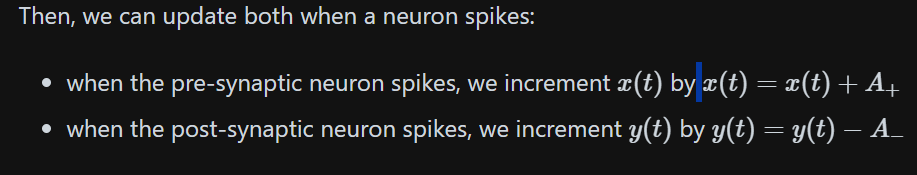

In [6]:
import numpy as np
import matplotlib.pyplot as plt

SIM_PER_TIME = 100

def str2spikes(s, max_length=None, dt_per_char=SIM_PER_TIME, offset=0):
    if max_length is None: max_length = len(s)

    spikes = []
    for i in range(max_length):
        for _ in range(offset):
            spikes.append(False)
        spikes.append(i < len(s) and s[i] != ' ')
        for _ in range(dt_per_char - offset - 1):
            spikes.append(False)

    return spikes

def clone(arr):
    return arr[:]

def clone2d(arr):
    return [clone(a) for a in arr]

def plotDWView(pre_spike_strs, post_spike_strs, show_w=True, options=None, offsets={}, gmin=0, gmax=1, tau_plus=20.0, tau_minus=20.0, a_plus=0.01, a_minus=0.011):
    if options is None:
        options = {}
        
    max_length_string = max(len(s) for s in pre_spike_strs+post_spike_strs)
    pre_spikes  = [str2spikes(ps, int(max_length_string * 1.2), offset=offsets.get(('pre', idx), 0)) for idx, ps in enumerate(pre_spike_strs)]
    post_spikes = [str2spikes(ps, int(max_length_string * 1.2), offset=offsets.get(('post', idx), 0)) for idx, ps in enumerate(post_spike_strs)]

    all_spikes = pre_spikes + post_spikes

    padding = options.get('display', {}).get('padding', 5)
    label_width = 30
    padding_left = padding + label_width + padding
    padding_between_spike_view = 5
    padding_between_graphs = 20
    padding_between_weight_view = 5

    per_spike_height = 15
    per_graph_height = 70
    per_w_height = 100 if show_w else 0
    
    num_pre_neurons  = len(pre_spikes)
    num_post_neurons = len(post_spikes)
    
    spike_display_height = per_spike_height * (num_pre_neurons + num_post_neurons)
    graph_display_height = per_graph_height * (num_pre_neurons + num_post_neurons)
    dw_display_height = (per_w_height + padding_between_weight_view) * num_post_neurons
    
    height = spike_display_height + graph_display_height + padding_between_spike_view * (num_pre_neurons + num_post_neurons) + dw_display_height + 2 * padding + padding_between_graphs * (num_pre_neurons + num_post_neurons - 1)
    width = options.get('display', {}).get('width', 1000)
    
    fig, ax = plt.subplots(figsize=(width / 100, height / 100))
    
    all_spikes = pre_spikes + post_spikes
    
    sim_time = max(len(s) for s in all_spikes)
    
    # Initialize weights and other variables
    x = np.zeros((sim_time, num_pre_neurons))
    y = np.zeros((sim_time, num_post_neurons))
    w = np.zeros((sim_time, num_pre_neurons, num_post_neurons))
    
    dt = 10 / SIM_PER_TIME
    weights = STDPWeights(num_pre_neurons, num_post_neurons, tau_plus=tau_plus, tau_minus=tau_minus, a_plus=a_plus, a_minus=a_minus, g_min=gmin, g_max=gmax)

    for t in range(sim_time-1):
        preSpikes  = np.array([s[t] for s in pre_spikes])
        postSpikes = np.array([s[t] for s in post_spikes])

        weights.step(dt)
        weights.updateWeights(preSpikes, postSpikes)

        x[t+1] = clone(weights.x)
        y[t+1] = clone(weights.y)
        w[t+1] = clone2d(weights.w) if len(weights.w) > 0 else np.zeros((num_pre_neurons, num_post_neurons))
    
    
    spike_scale_x = np.linspace(padding_left, width + padding, sim_time)
    
    for i in range(num_pre_neurons + num_post_neurons):
        is_pre_synaptic = i < num_pre_neurons
        is_post_synaptic = not is_pre_synaptic
        spikes = all_spikes[i]
        neuron_index = i if is_pre_synaptic else i - num_pre_neurons
        color = plt.get_cmap('tab10')(neuron_index if is_pre_synaptic else 9 - (neuron_index % 10))
        y_loc = padding + i * (per_spike_height + per_graph_height + padding_between_graphs + padding_between_spike_view) + (is_post_synaptic * (per_w_height + padding_between_weight_view) * neuron_index)

        ax.add_patch(plt.Rectangle((padding, y_loc), label_width, per_spike_height + per_graph_height + padding_between_spike_view + (0 if is_pre_synaptic else (per_w_height + padding_between_weight_view)), edgecolor='#333', facecolor='#EEE' if is_pre_synaptic else '#777'))
        ax.text(padding + label_width / 2, y_loc + (per_spike_height + per_graph_height + padding_between_spike_view + (0 if is_pre_synaptic else (per_w_height + padding_between_weight_view))) / 2, f"{'pre' if is_pre_synaptic else 'post'} #{neuron_index + 1}", ha='center', va='center', rotation='vertical', fontsize=10, color='#333' if is_pre_synaptic else '#EEE')
        
        spike_times = [t for t, spike in enumerate(spikes) if spike]

        
        for t in spike_times:
            display_x = spike_scale_x[t]
            ax.plot([display_x, display_x], [y_loc, y_loc + per_spike_height], color=color, linewidth=5)
            ax.plot([display_x, display_x], [y_loc, height], color=color, linewidth=1, linestyle=(0, (1, 7)))

        
        trace_var = x if is_pre_synaptic else y
        trace_val = trace_var[:, neuron_index]
        max_trace_val = np.max(np.abs(trace_val))
        ax.plot(spike_scale_x[:len(trace_val)], -trace_val*(per_graph_height / max_trace_val) + y_loc + per_spike_height + padding_between_spike_view + (per_graph_height if is_pre_synaptic else 0), color=color)
        
        if is_post_synaptic and show_w:
            max_prepost_w = np.max(np.abs(w[:, :, neuron_index]))
            for pre_neuron_index in range(num_pre_neurons):
                pre_color = plt.get_cmap('tab10')(pre_neuron_index)
                prepost_w = w[:, pre_neuron_index, neuron_index]
                ax.plot(spike_scale_x[:len(prepost_w)], -prepost_w*(per_w_height / max_prepost_w) + y_loc + per_graph_height + per_spike_height + per_w_height + 2*padding_between_spike_view, color=pre_color)
    
    plt.gca().invert_yaxis() 
    
    # remove axis
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # remove ticks
    ax.tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, left=False, right=False, labelleft=False)

    plt.show()

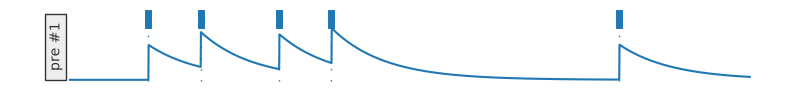

In [7]:
plotDWView(['   x x  x x          x'], [], False)

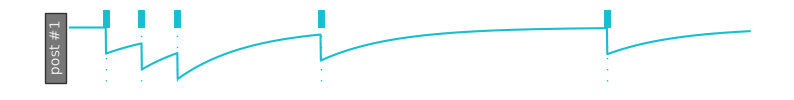

In [8]:
plotDWView([], [' xxx   x       x'], False)

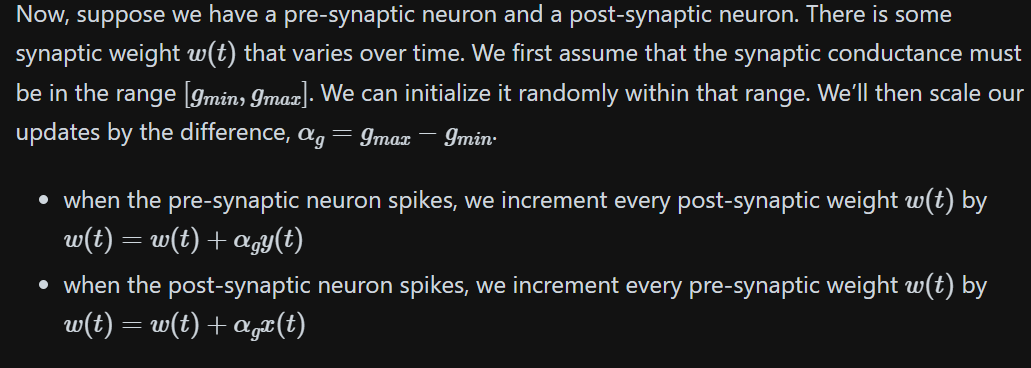

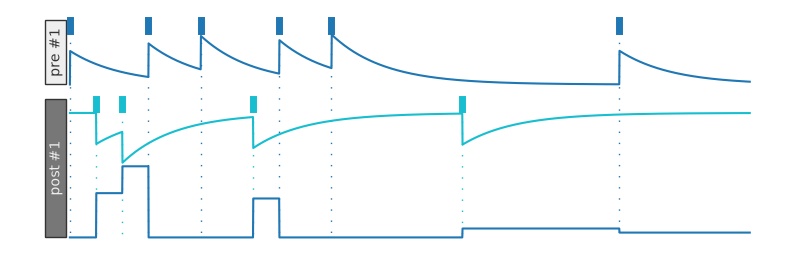

In [9]:
plotDWView(['x  x x  x x          x'],
           [' xx    x       x'])

If our post-synaptic neuron tends to spike right after our pre-synaptic neuron, the connection between the two strengthens:

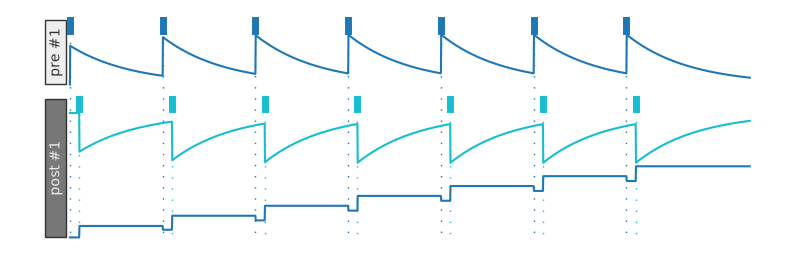

In [10]:
plotDWView(['x  x  x  x  x  x  x'],
           ['x  x  x  x  x  x  x'], offsets={('pre', 0): 0, ('post', 0): 30})

If our post-synaptic neuron tends to spike right before our pre-synaptic neuron, the connection between the two weakens (here, setting g_min to -1 so that the weight can be negative):

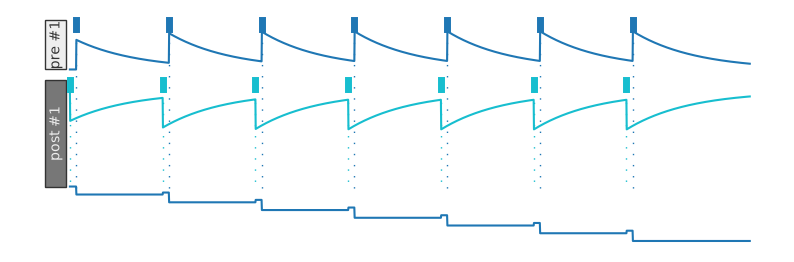

In [11]:
plotDWView(['x  x  x  x  x  x  x'],
           ['x  x  x  x  x  x  x'], offsets={('pre', 0): 20, ('post', 0): 0}, gmin=-1)

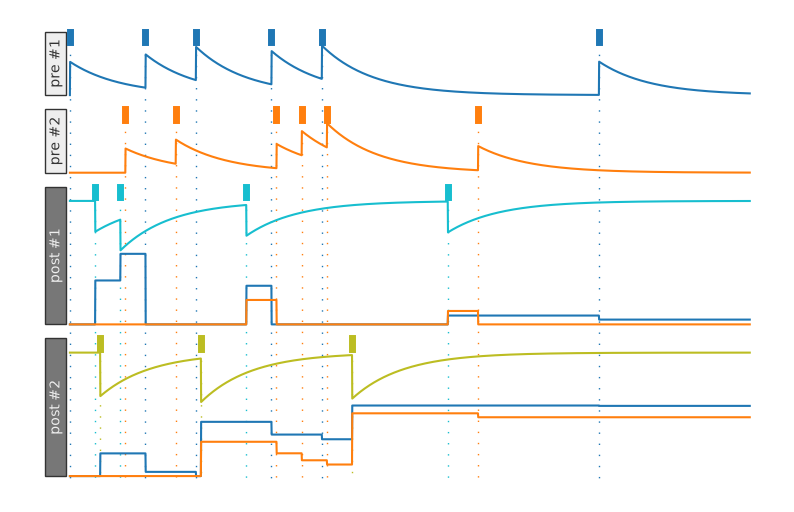

In [12]:
plotDWView(
  # Pre-synaptic spikes
  [
    "x  x x  x x          x",
    "  x x   xxx     x     ",
  ],
  # Post-synaptic spikes
  [
    " xx    x       x       ",
    " x   x     x           ",
  ], offsets={('pre', 0): 0, ('pre', 1): 20, ('post', 0): 0, ('post', 1): 20})